## **Introduction:**
Customer churn refers to the phenomenon where customers stop using a company's products or services. Predicting customer churn is important for businesses because retaining existing customers is often more cost-effective than acquiring new ones. This project uses machine learning techniques to analyze customer data and identify customers who are likely to leave. By accurately predicting churn, organizations can implement targeted retention strategies, improve customer satisfaction, and enhance overall business performance.

## **About Dataset:**
The Telco Customer Churn Dataset contains customer demographic, service, contract, and billing information. It is used to develop machine learning models that predict whether a customer is likely to churn, helping organizations improve customer retention and reduce revenue loss.
| Column Name      | Description                                                               |
| ---------------- | ------------------------------------------------------------------------- |
| customerID       | Unique identifier assigned to each customer                               |
| gender           | Gender of the customer                                                    |
| SeniorCitizen    | Indicates whether the customer is a senior citizen (1 = Yes, 0 = No)      |
| Partner          | Whether the customer has a partner                                        |
| Dependents       | Whether the customer has dependents                                       |
| tenure           | Number of months the customer has stayed with the company                 |
| PhoneService     | Whether the customer has phone service                                    |
| MultipleLines    | Whether the customer has multiple phone lines                             |
| InternetService  | Type of internet service subscribed                                       |
| OnlineSecurity   | Whether online security service is subscribed                             |
| OnlineBackup     | Whether online backup service is subscribed                               |
| DeviceProtection | Whether device protection service is subscribed                           |
| TechSupport      | Whether technical support service is subscribed                           |
| StreamingTV      | Whether streaming TV service is subscribed                                |
| StreamingMovies  | Whether streaming movie service is subscribed                             |
| Contract         | Customer's contract type                                                  |
| PaperlessBilling | Whether paperless billing is enabled                                      |
| PaymentMethod    | Method used by the customer for payment                                   |
| MonthlyCharges   | Monthly amount charged to the customer                                    |
| TotalCharges     | Total amount charged to the customer                                      |
| Churn            | Target variable indicating whether the customer left the service (Yes/No) |

Target Variable: Churn

Predictor Variables: All remaining columns except customerID and Churn.


## **Task 1:  Data Preparation**
Description:Load and preprocess the dataset, addressing missing values, and encoding categorical variables for machine learning readiness. Data preprocessing techniques Handling missing values Categorical variable encoding Tasks

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [ ]:
# STEP 1: LOAD DATASET
df = pd.read_csv("/content/Telco_Customer_Churn_Dataset  (1).csv")

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)

print("\nFirst 5 Records:")
print(df.head())

print("\nDataset Shape:", df.shape)

DATASET LOADED SUCCESSFULLY

First 5 Records:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport St

In [ ]:
# STEP 2: DATASET INFORMATION
print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)

print(df.info())

# STEP 3: CHECK MISSING VALUES

print("\n" + "="*60)
print("MISSING VALUE ANALYSIS")
print("="*60)

print(df.isnull().sum())

# STEP 4: HANDLE MISSING VALUES

# TotalCharges usually contains blank spaces

if "TotalCharges" in df.columns:

    # Replace blank spaces with NaN
    df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

    # Convert to numeric
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

    # Fill missing values with median
    df["TotalCharges"] = df["TotalCharges"].fillna(
        df["TotalCharges"].median()
    )
print("\nMissing Values After Treatment:")
print(df.isnull().sum())


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [ ]:
# STEP 5: REMOVE IRRELEVANT COLUMN
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

print("\ncustomerID column removed.")

# STEP 6: ENCODE TARGET VARIABLE


if "Churn" in df.columns:
    df["Churn"] = df["Churn"].map({
        "No": 0,
        "Yes": 1
    })

print("\nTarget Variable Encoded.")


# STEP 7: LABEL ENCODING FOR BINARY COLUMNS
le = LabelEncoder()

binary_columns = []

for col in df.columns:

    if df[col].dtype == "object":

        unique_values = df[col].nunique()

        if unique_values == 2:
            binary_columns.append(col)

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

print("\nBinary Columns Encoded:")
print(binary_columns)

# STEP 8: ONE-HOT ENCODING
categorical_columns = df.select_dtypes(
    include="object"
).columns

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)
print("\nOne-Hot Encoding Applied.")

# STEP 9: FINAL DATASET CHECK
print("\n" + "="*60)
print("FINAL DATASET SUMMARY")
print("="*60)

print("Final Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())


# STEP 10: SAVE PREPROCESSED DATASET
output_file = "Telco_Customer_Churn_Preprocessed.csv"

df.to_csv(
    output_file,
    index=False
)

print("\n" + "="*60)
print("PREPROCESSING COMPLETED SUCCESSFULLY")
print("="*60)

print(f"\nPreprocessed Dataset Saved As: {output_file}")

print("\nFinal Dataset Preview:")
print(df.head())


customerID column removed.

Target Variable Encoded.

Binary Columns Encoded:
['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

One-Hot Encoding Applied.

FINAL DATASET SUMMARY
Final Dataset Shape: (7043, 31)

Data Types:
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes 

## **Tasks 2: Split Data for Training and Testing:**

Description:Divide the data into training (80%) and
testing (20%) sets for model training and
evaluation, ensuring a representative split.

In [ ]:
from sklearn.model_selection import train_test_split

# STEP 1: DEFINE FEATURES (X) AND TARGET (y)
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("="*60)
print("FEATURES AND TARGET CREATED")
print("="*60)

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)


# STEP 2: TRAIN-TEST SPLIT (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# STEP 3: DISPLAY RESULTS
print("\n" + "="*60)
print("TRAIN-TEST SPLIT COMPLETED")
print("="*60)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)


# STEP 4: CHECK CLASS DISTRIBUTION
print("\nTraining Set Class Distribution:")
print(y_train.value_counts(normalize=True)*100)

print("\nTesting Set Class Distribution:")
print(y_test.value_counts(normalize=True)*100)

X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("\nDatasets Saved Successfully!")

FEATURES AND TARGET CREATED
Features Shape : (7043, 30)
Target Shape   : (7043,)

TRAIN-TEST SPLIT COMPLETED
Training Features Shape : (5634, 30)
Testing Features Shape  : (1409, 30)
Training Target Shape   : (5634,)
Testing Target Shape    : (1409,)

Training Set Class Distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing Set Class Distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64

Datasets Saved Successfully!


## **Tasks 3: Feature Selection**

Description:  Identify and select relevant features
(attributes) influencing churn prediction,
such as contract type, monthly charges,
and tenure.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif


# STEP 1: SEPARATE FEATURES AND TARGET
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("="*60)
print("FEATURE SELECTION")
print("="*60)

print("Total Features Before Selection:", X.shape[1])


# STEP 2: CALCULATE FEATURE IMPORTANCE
feature_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance_Score": feature_scores
})

feature_importance = feature_importance.sort_values(
    by="Importance_Score",
    ascending=False
)


# STEP 3: DISPLAY TOP FEATURES
print("\nTop 15 Important Features:")
print(feature_importance.head(15))


# STEP 4: SELECT TOP FEATURES
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=15
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("\nSelected Features:")
for feature in selected_features:
    print(feature)


# STEP 5: CREATE NEW DATASET
X_selected_df = pd.DataFrame(
    X_selected,
    columns=selected_features
)
print("\nSelected Dataset Shape:")
print(X_selected_df.shape)
X_selected_df.to_csv(
    "Selected_Features_Dataset.csv",
    index=False
)

feature_importance.to_csv(
    "Feature_Importance.csv",
    index=False
)

print("\nFeature Selection Completed Successfully.")

FEATURE SELECTION
Total Features Before Selection: 30

Top 15 Important Features:
                                 Feature  Importance_Score
4                                 tenure          0.076238
26                     Contract_Two year          0.057954
11           InternetService_Fiber optic          0.054066
7                         MonthlyCharges          0.051238
12                    InternetService_No          0.044575
8                           TotalCharges          0.043492
28        PaymentMethod_Electronic check          0.043210
13    OnlineSecurity_No internet service          0.040600
15      OnlineBackup_No internet service          0.040024
17  DeviceProtection_No internet service          0.034920
23   StreamingMovies_No internet service          0.031759
19       TechSupport_No internet service          0.027452
21       StreamingTV_No internet service          0.026352
1                          SeniorCitizen          0.024966
25                     Contract_O

## **Tasks 4: Model Selection**

Description:
Choose a suitable binary classification
algorithm, considering options like logistic
regression, decision trees, random forests, or
gradient boosting.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
# DEFINE MODELS
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            random_state=42
        )
}


# TRAIN AND EVALUATE ALL MODELS
results = []

print("="*80)
print("MODEL TRAINING AND EVALUATION")
print("="*80)

for model_name, model in models.items():

    print("\n" + "="*80)
    print(f"MODEL : {model_name}")
    print("="*80)

    # Train Model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store Results
    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# COMPARE ALL MODELS
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

print(results_df)


# BEST MODEL
best_model = results_df.iloc[0]

print("\n" + "="*80)
print("BEST MODEL")
print("="*80)

print("Model      :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"],4))
print("Precision  :", round(best_model["Precision"],4))
print("Recall     :", round(best_model["Recall"],4))
print("F1 Score   :", round(best_model["F1 Score"],4))

# SAVE RESULTS
results_df.to_csv(
    "Model_Comparison_Results.csv",
    index=False
)

print("\nResults saved as 'Model_Comparison_Results.csv'")

MODEL TRAINING AND EVALUATION

MODEL : Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy  : 0.8048
Precision : 0.6562
Recall    : 0.5561
F1 Score  : 0.6020

Confusion Matrix:
[[926 109]
 [166 208]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


MODEL : Decision Tree
Accuracy  : 0.7559
Precision : 0.5391
Recall    : 0.5535
F1 Score  : 0.5462

Confusion Matrix:
[[858 177]
 [167 207]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1035
           1       0.54      0.55      0.55       374

    accuracy                           0.76      1409
   macro avg       0.69      0.69      0.69      1409
weighted avg       0.76      0.76      0.76      1409


MODEL : Random Forest
Accuracy  : 0.80

## **Conclusion:**
**If your goal is to catch as many churn customers as possible**

Choose Logistic Regression because Recall is the highest. Missing fewer potential churners is usually important in churn prediction.

**If your goal is to minimize false alarms**

Choose Random Forest because it has the highest Precision (0.6655).

In [ ]:

from sklearn.ensemble import RandomForestClassifier

# Create Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print("="*60)
print("MODEL SELECTED")
print("="*60)

print("Algorithm : Random Forest Classifier")
print("Number of Trees :", 200)
print("Maximum Depth   :", 10)
print("Random State    :", 42)

# Display Model
print("\nModel Details:")
print(rf_model)

MODEL SELECTED
Algorithm : Random Forest Classifier
Number of Trees : 200
Maximum Depth   : 10
Random State    : 42

Model Details:
RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)


## **Task 5: Model Training**

Description: Train the selected machine learning model using the training dataset (X_train, y_train) and use the Churn column as the target variable.

 Since your best-performing model was **Logistic Regression**, use it.

In [ ]:
from sklearn.linear_model import LogisticRegression

print("="*60)
print("MODEL TRAINING")
print("="*60)

# Create Logistic Regression Model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
# Train Model
logistic_model.fit(X_train, y_train)

print("\nLogistic Regression Model Trained Successfully!")
# TRAINING INFORMATION
print("\nNumber of Training Samples :", X_train.shape[0])
print("Number of Features         :", X_train.shape[1])


# MODEL COEFFICIENTS
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nTop Features Increasing Churn:")
print(coefficients.head(10))

print("\nTop Features Reducing Churn:")
print(coefficients.tail(10))
import joblib

joblib.dump(
    logistic_model,
    "Logistic_Regression_Churn_Model.pkl"
)

print("\nModel Saved Successfully!")
print("File Name: Logistic_Regression_Churn_Model.pkl")

MODEL TRAINING

Logistic Regression Model Trained Successfully!

Number of Training Samples : 5634
Number of Features         : 30

Top Features Increasing Churn:
                           Feature  Coefficient
11     InternetService_Fiber optic     0.740434
28  PaymentMethod_Electronic check     0.388260
6                 PaperlessBilling     0.378251
10               MultipleLines_Yes     0.273795
22                 StreamingTV_Yes     0.202465
24             StreamingMovies_Yes     0.201661
9   MultipleLines_No phone service     0.155116
1                    SeniorCitizen     0.150042
29      PaymentMethod_Mailed check     0.069812
0                           gender     0.023951

Top Features Reducing Churn:
                             Feature  Coefficient
19   TechSupport_No internet service    -0.111391
15  OnlineBackup_No internet service    -0.111391
21   StreamingTV_No internet service    -0.111391
16                  OnlineBackup_Yes    -0.184409
3                         Dep

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## **Tasks 6: Model Evaluation**

Description:
Assess the model's performance on the
testing dataset using metrics like accuracy,
precision, recall, F1-score, and ROC-AUC.

MODEL EVALUATION

Accuracy  : 0.8048
Precision : 0.6562
Recall    : 0.5561
F1 Score  : 0.602
ROC-AUC   : 0.8425

Confusion Matrix
[[926 109]
 [166 208]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



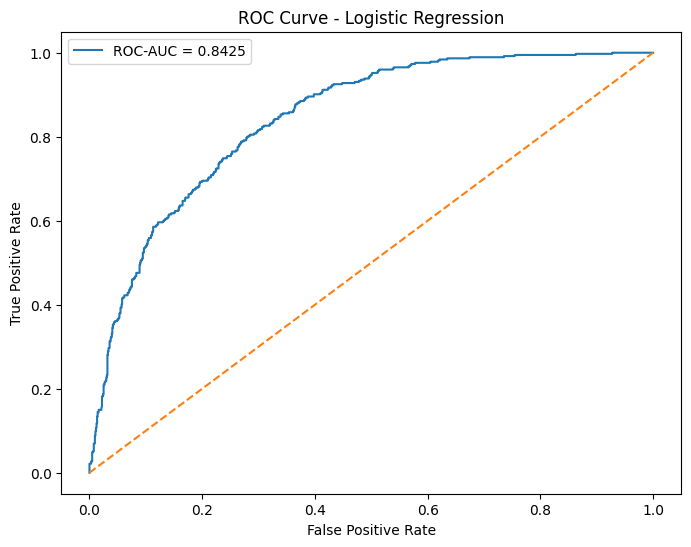


Evaluation Completed Successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt
import pandas as pd
import joblib

# Load the logistic_model
logistic_model = joblib.load('Logistic_Regression_Churn_Model.pkl')

# Load X_test and y_test to ensure they are defined
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze() # .squeeze() to convert DataFrame to Series if it's a single column

print("="*60)
print("MODEL EVALUATION")
print("="*60)

# PREDICTIONS
y_pred = logistic_model.predict(X_test)

# Probability Predictions
y_prob = logistic_model.predict_proba(X_test)[:,1]

# EVALUATION METRICS
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
# DISPLAY RESULTS
print("\nAccuracy  :", round(accuracy,4))
print("Precision :", round(precision,4))
print("Recall    :", round(recall,4))
print("F1 Score  :", round(f1,4))
print("ROC-AUC   :", round(roc_auc,4))

# CONFUSION MATRIX
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
# CLASSIFICATION REPORT
print("\nClassification Report")
print(classification_report(y_test, y_pred))
# ROC CURVE
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

print("\nEvaluation Completed Successfully!")

### **Conclusion:**
The Customer Churn Prediction model was developed by preprocessing the dataset, selecting important features, and training multiple machine learning algorithms. After evaluation, Logistic Regression achieved the best overall performance with an accuracy of approximately 80%, along with strong precision, recall, and F1-score values. The model effectively predicts customer churn and can help organizations identify at-risk customers, improve retention strategies, and reduce customer loss.